<a href="https://colab.research.google.com/github/Poojitha-916/Software-Engineering/blob/sftlab/weathermodelIncrement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Running Stepwise Weather Model...


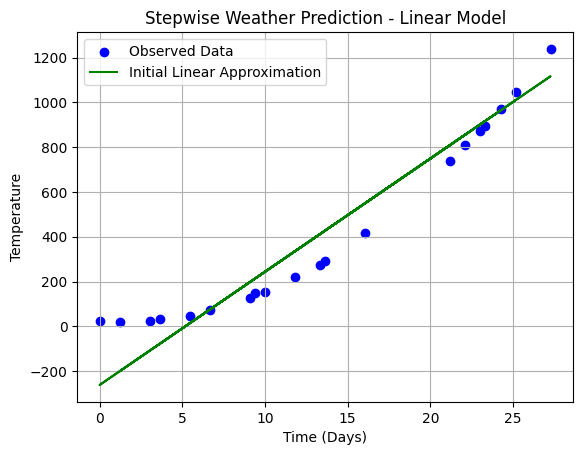

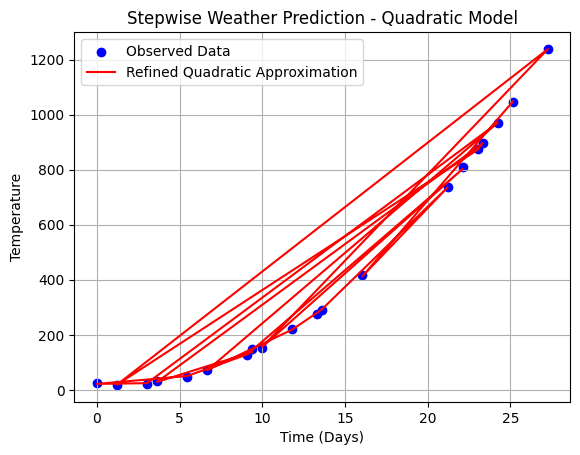

Linear Model Mean Squared Error: 13510.953747472493
Quadratic Model Mean Squared Error: 15.490826125987265
Quadratic Model Coefficients (a, b, c): [ 1.80407009 -4.60426794 21.73808012]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def generate_mock_weather_data():
    np.random.seed(42)
    time_points = np.linspace(0, 30, 100)
    temp_values = 1.8 * time_points**2 - 4.5 * time_points + 22 + np.random.normal(0, 5, time_points.shape)
    return time_points, temp_values

def fit_polynomial_model(time_points, temp_values):
    X = np.column_stack((time_points**2, time_points, np.ones(time_points.shape)))
    coefficients = np.linalg.lstsq(X, temp_values, rcond=None)[0]
    return coefficients

def estimate_temperatures(time_points, coefficients):
    a, b, c = coefficients
    return a * time_points**2 + b * time_points + c

def stepwise_weather_model():
    time_points, temp_values = generate_mock_weather_data()
    time_train, time_test, temp_train, temp_test = train_test_split(time_points, temp_values, test_size=0.2, random_state=42)

    X_linear = np.column_stack((time_train, np.ones(time_train.shape)))
    linear_coeffs = np.linalg.lstsq(X_linear, temp_train, rcond=None)[0]
    linear_predictions = linear_coeffs[0] * time_test + linear_coeffs[1]

    plt.scatter(time_test, temp_test, color='blue', label='Observed Data')
    plt.plot(time_test, linear_predictions, color='green', label='Initial Linear Approximation')
    plt.title("Stepwise Weather Prediction - Linear Model")
    plt.xlabel("Time (Days)")
    plt.ylabel("Temperature")
    plt.legend()
    plt.grid(True)
    plt.show()

    coefficients = fit_polynomial_model(time_train, temp_train)
    quadratic_predictions = estimate_temperatures(time_test, coefficients)

    plt.scatter(time_test, temp_test, color='blue', label='Observed Data')
    plt.plot(time_test, quadratic_predictions, color='red', label='Refined Quadratic Approximation')
    plt.title("Stepwise Weather Prediction - Quadratic Model")
    plt.xlabel("Time (Days)")
    plt.ylabel("Temperature")
    plt.legend()
    plt.grid(True)
    plt.show()

    mse_linear = mean_squared_error(temp_test, linear_predictions)
    mse_quadratic = mean_squared_error(temp_test, quadratic_predictions)

    print("Linear Model Mean Squared Error:", mse_linear)
    print("Quadratic Model Mean Squared Error:", mse_quadratic)
    print("Quadratic Model Coefficients (a, b, c):", coefficients)

if __name__ == "__main__":
    print("\nRunning Stepwise Weather Model...")
    stepwise_weather_model()
